In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
from funcs import *
from processing_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_260126/30cm/')

#figpath = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/Figures/'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Wave analysis
**The measurements were conducted Spring 2026 by Kjersti Stangeland.**

**This notebook analyzes wave gauge measurements of parameters:**

*Wave maker settings*
* 1.225 Hz frequency
* 0.471 V amplitude
* 0.3 m water depth
* 60*frequency periods ran
* 60 second trigger
* NO PLATES, empty tank

*Probe placements*
* $P_0$: 4.86 meters after paddle
* $P_1$: 6.69 meters after paddle
* $P_2$: 7.87 meters after paddle
* $P_3$: 9.15 meters after paddle

*The plates will be placed between 6.34 m - 9.38 m.*

In [95]:
# Change parameters here

base_path = '/Users/kjesta/Desktop/LABDATA/Kjersti_260126/No_plates/30cm/f1225/a0471'

filename = '30cm_f1225_a0471'

# For plotting
freq = 1.225 # in Hz
amp = 0.471 # in voltage
depth = 0.30 # in meters

# File name for output txt file
output_path = os.path.join(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No_plates/30cm', '30cm_f1225_a0471_wave_parameters.txt')
# Paths to raw data files
r1_path = os.path.join(base_path, 'f1225a0471h03r1.csv')
r2_path = os.path.join(base_path, 'f1225a0471h03r2.csv')
r3_path = os.path.join(base_path, 'f1225a0471h03r3.csv')

In [96]:
r1_raw = pd.read_csv(r1_path)
r2_raw = pd.read_csv(r2_path)
r3_raw = pd.read_csv(r3_path)

headers = ['time', 'P_0', 'P_1', 'P_2', 'P_3', 'sound_speed']

r1_raw.columns = headers
r2_raw.columns = headers
r3_raw.columns = headers

# Post processing steps:

# 1) Remove noise (probe artefacts) and convert time to seconds
r1_clean = clean(r1_raw)
r2_clean = clean(r2_raw)
r3_clean = clean(r3_raw)

In [97]:
# Positions of probes
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # Base positions, meters from wave maker

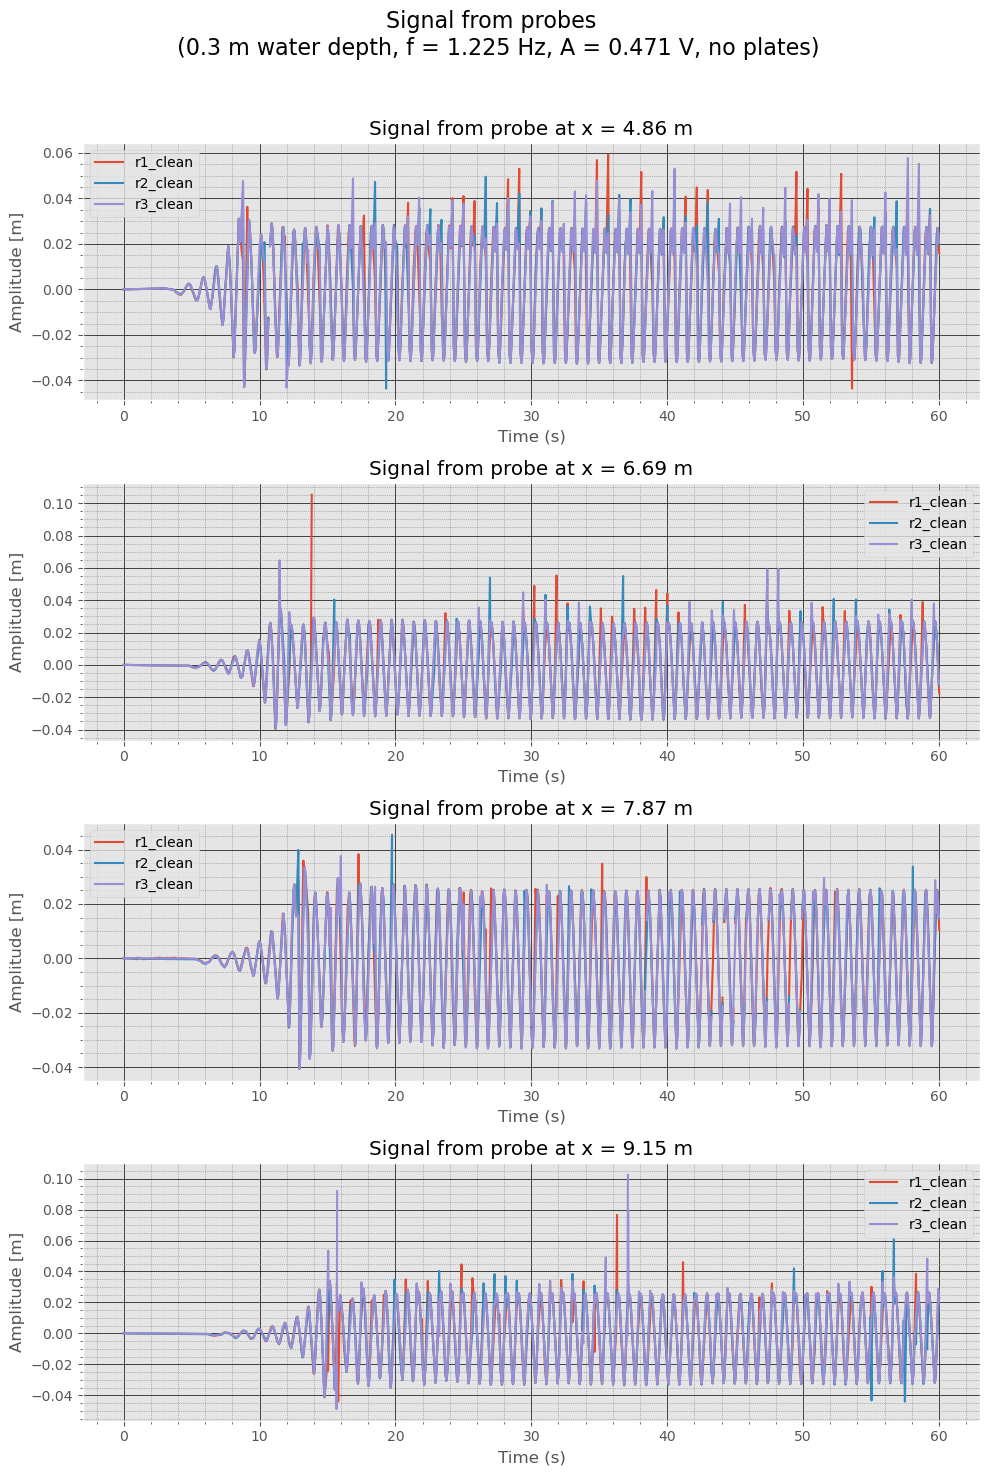

In [98]:
fig, ax = plt.subplots(4,1, figsize=(10, 15))

# P0
ax[0].plot(r1_clean['time'], r1_clean['P_0'], label='r1_clean')
ax[0].plot(r2_clean['time'], r2_clean['P_0'], label='r2_clean')
ax[0].plot(r3_clean['time'], r3_clean['P_0'], label='r3_clean')

# P1
ax[1].plot(r1_clean['time'], r1_clean['P_1'], label='r1_clean')
ax[1].plot(r2_clean['time'], r2_clean['P_1'], label='r2_clean')
ax[1].plot(r3_clean['time'], r3_clean['P_1'], label='r3_clean')

# P2
ax[2].plot(r1_clean['time'], r1_clean['P_2'], label='r1_clean')
ax[2].plot(r2_clean['time'], r2_clean['P_2'], label='r2_clean')
ax[2].plot(r3_clean['time'], r3_clean['P_2'], label='r3_clean')

# P3
ax[3].plot(r1_clean['time'], r1_clean['P_3'], label='r1_clean')
ax[3].plot(r2_clean['time'], r2_clean['P_3'], label='r2_clean')
ax[3].plot(r3_clean['time'], r3_clean['P_3'], label='r3_clean')

for axs in ax:
    axs.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    axs.legend()
    axs.set_xlabel('Time (s)')
    axs.set_ylabel('Amplitude [m]')
    axs.minorticks_on()

fig.suptitle(f'Signal from probes \n ({depth} m water depth, f = {freq} Hz, A = {amp} V, no plates)', fontsize=16)
ax[0].set_title(f'Signal from probe at x = {x_probe_pos[0]} m')
ax[1].set_title(f'Signal from probe at x = {x_probe_pos[1]} m')
ax[2].set_title(f'Signal from probe at x = {x_probe_pos[2]} m')
ax[3].set_title(f'Signal from probe at x = {x_probe_pos[3]} m')
plt.tight_layout(rect=[0, 0, 1, 0.96])

In [99]:
# If needed, correct outliers and interpolate missing data
threshold = 0.0006  # Set threshold for spike detection

r1_corr = correct_spikes(r1_clean, threshold)
r2_corr = correct_spikes(r2_clean, threshold)
r3_corr = correct_spikes(r3_clean, threshold)

Column P_0: Removed 129422 spikes in 20 passes.
Column P_1: Removed 138872 spikes in 20 passes.
Column P_2: Removed 129404 spikes in 20 passes.
Column P_3: Removed 126422 spikes in 20 passes.
Column P_0: Removed 122824 spikes in 20 passes.
Column P_1: Removed 139741 spikes in 20 passes.
Column P_2: Removed 128657 spikes in 20 passes.
Column P_3: Removed 124441 spikes in 20 passes.
Column P_0: Removed 130778 spikes in 20 passes.
Column P_1: Removed 142552 spikes in 20 passes.
Column P_2: Removed 131299 spikes in 20 passes.
Column P_3: Removed 127787 spikes in 20 passes.


In [100]:
# 2) Cut out invalid data (build-up time and reflections)
# Time of first front arrival at P0
wave_maker_build_up_time =  12 # seconds

r1_valid = cut_out_valid_data(r1_corr, freq, depth, wave_maker_build_up_time, x_probe_pos)
r2_valid = cut_out_valid_data(r2_corr, freq, depth, wave_maker_build_up_time, x_probe_pos)
r3_valid = cut_out_valid_data(r3_corr, freq, depth, wave_maker_build_up_time, x_probe_pos)

----- Cutting out invalid data -----
Time after transient front reaches each probe: [12.         16.51851852 19.43209877 22.59259259]

Reflection arrival times at each probe: [56.4580721  51.32806853 48.02019737 44.43199815]

Time window between build-up and reflection at each probe: [44.4580721  34.80955001 28.58809861 21.83940556]

Maximum number of usable wave periods at each probe: [54.46113833 42.64169876 35.0204208  26.75327181]
-------------------------------------------------
----- Cutting out invalid data -----
Time after transient front reaches each probe: [12.         16.51851852 19.43209877 22.59259259]

Reflection arrival times at each probe: [56.4580721  51.32806853 48.02019737 44.43199815]

Time window between build-up and reflection at each probe: [44.4580721  34.80955001 28.58809861 21.83940556]

Maximum number of usable wave periods at each probe: [54.46113833 42.64169876 35.0204208  26.75327181]
-------------------------------------------------
----- Cutting out inva

In [101]:
# 3) Detrend data, set mean water level to zero
r1_detrended = detrend(r1_valid)
r2_detrended = detrend(r2_valid)
r3_detrended = detrend(r3_valid)

# Checking that all probes now have zero mean (still water level)
for col in ['P_0', 'P_1', 'P_2', 'P_3']:
    if np.mean(r1_detrended[col]) < 1e-15 or np.mean(r2_detrended[col]) < 1e-15 or np.mean(r3_detrended[col]) < 1e-15:
        print(f"Mean of column {col} is zero after detrending - all good here :)")
    else: 
        raise Exception(f"Mean of column {col} is not zero after detrending!")

run1 = r1_detrended
run2 = r2_detrended
run3 = r3_detrended

Mean of column P_0 is zero after detrending - all good here :)
Mean of column P_1 is zero after detrending - all good here :)
Mean of column P_2 is zero after detrending - all good here :)
Mean of column P_3 is zero after detrending - all good here :)


The wave maker takes some time to build a steady wave train. I therefore cut off the beginning of the time series, based on what I visually intepret as the steady wave train.

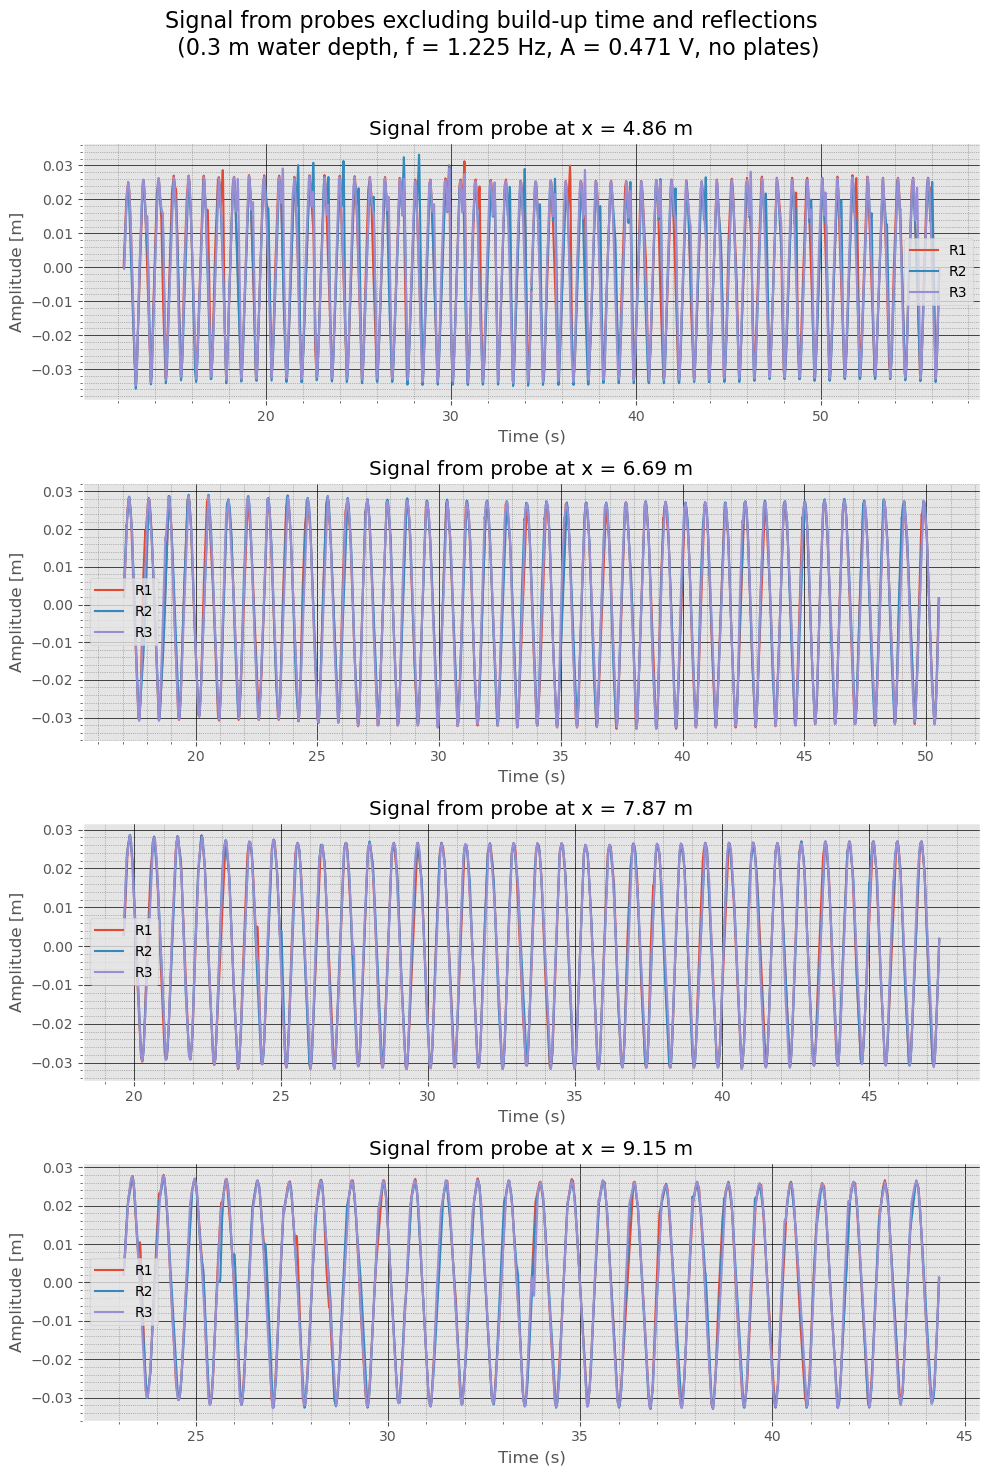

In [102]:
fig, ax = plt.subplots(4,1, figsize=(10, 15))

# P0
ax[0].plot(run1['time'], run1['P_0'], label='R1')
ax[0].plot(run2['time'], run2['P_0'], label='R2')
ax[0].plot(run3['time'], run3['P_0'], label='R3')

# P1
ax[1].plot(run1['time'], run1['P_1'], label='R1')
ax[1].plot(run2['time'], run2['P_1'], label='R2')
ax[1].plot(run3['time'], run3['P_1'], label='R3')

# P2
ax[2].plot(run1['time'], run1['P_2'], label='R1')
ax[2].plot(run2['time'], run2['P_2'], label='R2')
ax[2].plot(run3['time'], run3['P_2'], label='R3')

# P3
ax[3].plot(run1['time'], run1['P_3'], label='R1')
ax[3].plot(run2['time'], run2['P_3'], label='R2')
ax[3].plot(run3['time'], run3['P_3'], label='R3')

for axs in ax:
    axs.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    axs.legend()
    axs.set_xlabel('Time (s)')
    axs.set_ylabel('Amplitude [m]')
    axs.minorticks_on()

fig.suptitle(f'Signal from probes excluding build-up time and reflections \n ({depth} m water depth, f = {freq} Hz, A = {amp} V, no plates)', fontsize=16)
ax[0].set_title(f'Signal from probe at x = {x_probe_pos[0]} m')
ax[1].set_title(f'Signal from probe at x = {x_probe_pos[1]} m')
ax[2].set_title(f'Signal from probe at x = {x_probe_pos[2]} m')
ax[3].set_title(f'Signal from probe at x = {x_probe_pos[3]} m')
plt.tight_layout(rect=[0, 0, 1, 0.96])

In [103]:
# Standard deviation for each probe and run
std_P0_r1 = np.std(run1['P_0'])
std_P0_r2 = np.std(run2['P_0'])
std_P0_r3 = np.std(run3['P_0'])

std_P1_r1 = np.std(run1['P_1'])
std_P1_r2 = np.std(run2['P_1'])
std_P1_r3 = np.std(run3['P_1'])

std_P2_r1 = np.std(run1['P_2'])
std_P2_r2 = np.std(run2['P_2'])
std_P2_r3 = np.std(run3['P_2'])

std_P3_r1 = np.std(run1['P_3'])
std_P3_r2 = np.std(run2['P_3'])
std_P3_r3 = np.std(run3['P_3'])

# Taking the mean std for each probe across runs and calculating amplitude
amp_P0 = np.sqrt(2) * np.mean([std_P0_r1, std_P0_r2, std_P0_r3])
amp_P1 = np.sqrt(2) * np.mean([std_P1_r1, std_P1_r2, std_P1_r3])
amp_P2 = np.sqrt(2) * np.mean([std_P2_r1, std_P2_r2, std_P2_r3])
amp_P3 = np.sqrt(2) * np.mean([std_P3_r1, std_P3_r2, std_P3_r3])

In [104]:
"""
Estimating wavelength from frequency using linear wave theory.
The estimate_wavenumber function is defined in funcs.py
and uses Newton-Raphson iterative method to solve the dispersion relation.
"""
k = estimate_wavenumber(freq, depth)

# From wavenumber to wavelength
wl = 2 * np.pi / k

In [105]:
"""
Estimating phase speed and group speed using linear wave theory.
The phase speed c and group speed cg are calculated using the formulas:
(Kundu et al., Fluid Mechanics, 6th edition, p. 372).
c = omega / k
cg = (c / 2) * (1 + (2 * k * depth) / (sinh(2 * k * depth)))
where omega = 2 * pi * frequency
"""
c = 2 * np.pi * freq / k
cg = (c / 2) * (1 + (2 * k * depth) / (np.sinh(2 * k * depth)))

In [106]:
# Amplitude decay rate
dx = x_probe_pos[-1] - x_probe_pos[0]
da = amp_P0 - amp_P3
alpha = da / dx 

In [107]:
# Dimensionless parameters
kH = k * depth
ak = (amp_P0 * k)

## Summary of wave parameters

In [108]:
# Write to file
with open(output_path, 'w') as f:
    f.write(f'Summary of wave parameters for {filename}:\n')
    f.write('----------------------------------------------------------\n')
    f.write(f'Water depth: {depth} m, Frequency: {freq} Hz, Amplitude setting: {amp} V\n\n')
    f.write(f'Wavelength: {wl:.4f} m\n')
    f.write(f'Wavenumber: {k:.4f} 1/m\n')
    f.write(f'Phase speed: {c:.4f} m/s\n')
    f.write(f'Group speed: {cg:.4f} m/s\n\n')
    f.write('Dimensionless parameters:\n')
    f.write(f'ak = {ak:.4f}, kH = {kH:.4f}\n\n')
    f.write('Standard Deviation for each probe:\n')
    f.write(f'P0: {np.mean([std_P0_r1, std_P0_r2, std_P0_r3]):.4f} m\n')
    f.write(f'P1: {np.mean([std_P1_r1, std_P1_r2, std_P1_r3]):.4f} m\n')
    f.write(f'P2: {np.mean([std_P2_r1, std_P2_r2, std_P2_r3]):.4f} m\n')
    f.write(f'P3: {np.mean([std_P3_r1, std_P3_r2, std_P3_r3]):.4f} m\n\n')
    f.write(f'Wave Amplitude for each probe:\n')
    f.write(f'P0: {amp_P0:.4f} m\n')
    f.write(f'P1: {amp_P1:.4f} m\n')
    f.write(f'P2: {amp_P2:.4f} m\n')
    f.write(f'P3: {amp_P3:.4f} m\n\n')
    f.write(f'Amplitude Difference between P0 and P3: {amp_P0 - amp_P3:.5f} m\n')
    f.write(f'Spatial Amplitude Decay Rate: {alpha:.5f} m/m\n\n')
    f.write('Number of data points used for analysis after cutting out build-up time and reflections:\n')
    f.write('Run 1:\n')
    for probe in ['P_0', 'P_1', 'P_2', 'P_3']:
        f.write(f'{probe}: {run1[probe].notna().sum()} data points\n')
    f.write('Run 2:\n')
    for probe in ['P_0', 'P_1', 'P_2', 'P_3']:
        f.write(f'{probe}: {run2[probe].notna().sum()} data points\n')
    f.write('Run 3:\n')
    for probe in ['P_0', 'P_1', 'P_2', 'P_3']:
        f.write(f'{probe}: {run3[probe].notna().sum()} data points\n')

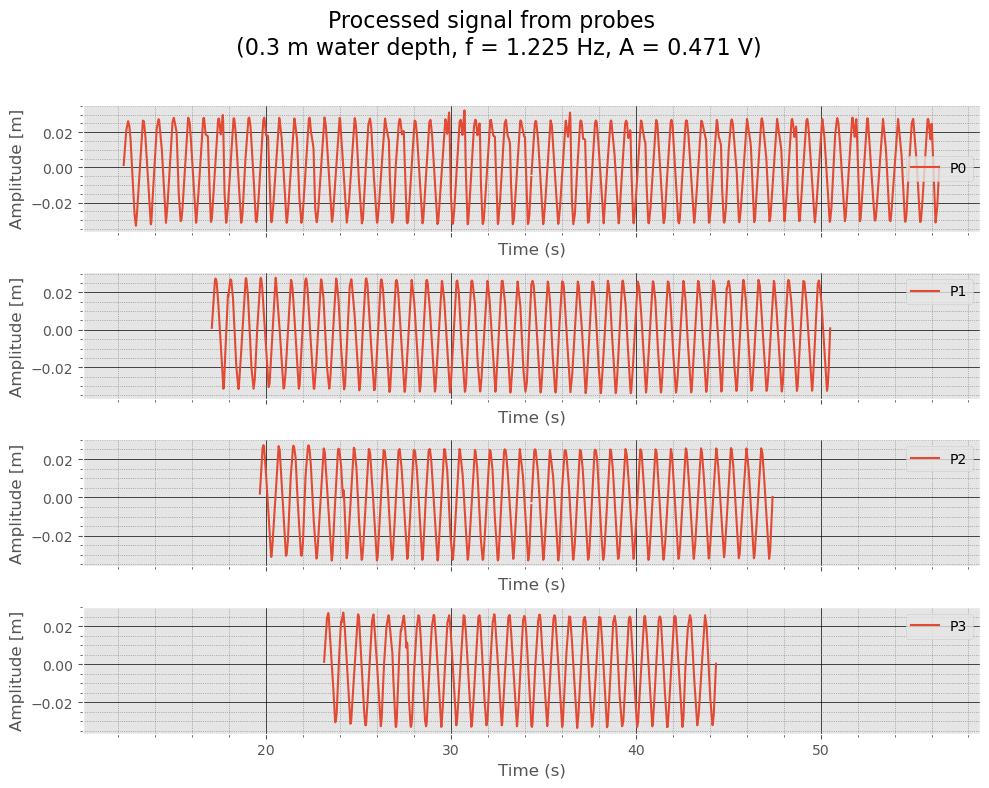

In [109]:
# Writing processed data to file
output_path = "/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/Processed_files"

r1_valid.to_csv(os.path.join(output_path, f'{filename}_r1_processed.csv'), index=False)
r2_valid.to_csv(os.path.join(output_path, f'{filename}_r2_processed.csv'), index=False)
r3_valid.to_csv(os.path.join(output_path, f'{filename}_r3_processed.csv'), index=False)

test = pd.read_csv(os.path.join(output_path, f'{filename}_r1_processed.csv'))

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

ax[0].plot(test['time'], test['P_0'], label='P0')
ax[1].plot(test['time'], test['P_1'], label='P1')
ax[2].plot(test['time'], test['P_2'], label='P2')
ax[3].plot(test['time'], test['P_3'], label='P3')

for axs in ax:
    axs.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    axs.legend()
    axs.set_xlabel('Time (s)')
    axs.set_ylabel('Amplitude [m]')
    axs.minorticks_on()

fig.suptitle(f'Processed signal from probes \n ({depth} m water depth, f = {freq} Hz, A = {amp} V)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])